In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
from flax import nnx

from confrdm_jax.flows import load_conditioner, make_mlp_conditioner
from confrdm_jax.likelihoods import create_crdm_likelihood_factory_approx, create_rdm_likelihood_factory_approx, create_rdm_two_accumulators_likelihood
from confrdm_jax.likelihoods.crdm_volterra import create_crdm_likelihood_volterra

jax.config.update("jax_enable_x64", True)

I0000 00:00:1782054201.079046    8833 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782054201.081263    8833 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782054202.707699    8833 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782054202.709313    8833 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
rngs = nnx.Rngs(default=jax.random.key(2026))

NUM_BINS  = 12
NUM_MID   = 128

conditioner_path = (
    Path("../outputs/rdm").absolute()
    / f"model.num_bins={NUM_BINS}/model.num_mid={NUM_MID}"
    / "optimizer=adam_cosine_decay/train_steps=500000/conditioner"
)

conditioner = load_conditioner(
    make_mlp_conditioner(num_in=3, num_bins=NUM_BINS, num_mid=NUM_MID, rngs=rngs),
    conditioner_path,
)
conditioner.eval()

In [3]:
dt_test = 0.005
t_max = 4.0

rt_grid = jnp.arange(dt_test, t_max + dt_test, dt_test)
resp = jnp.array([0, 1])

data = jnp.stack(
    [jnp.tile(rt_grid, reps=resp.shape[0]),
    jnp.repeat(resp, repeats=rt_grid.shape[0])],
).T

data_rev = data.at[data[:, 1] == 0, 0].multiply(-1)

data.shape

(1600, 2)

In [4]:
data_rev

Array([[-0.005,  0.   ],
       [-0.01 ,  0.   ],
       [-0.015,  0.   ],
       ...,
       [ 3.99 ,  1.   ],
       [ 3.995,  1.   ],
       [ 4.   ,  1.   ]], dtype=float64)

In [5]:
rdm_params = jnp.array([
    [1.0, 1.0, 1.2, 1.5, 0.3],
    [1.0, 1.5, 1.2, 1.5, 0.3],
    [1.0, 2.0, 1.2, 1.5, 0.3],
])

In [6]:
ll_fun_rdm_nn = create_rdm_likelihood_factory_approx(conditioner)(data)
ll_fun_rdm_analytical = create_rdm_two_accumulators_likelihood(data)

ll_rdm_nn = jnp.array([ll_fun_rdm_nn(jnp.log(p)) for p in rdm_params])
ll_rdm_analytical = jnp.array([ll_fun_rdm_analytical(jnp.log(p)) for p in rdm_params])

In [7]:
crdm_params = jnp.array([
    [1.0, 4.0, 0.2, 0.15, 0.8, 0.9, 0.3],
    [1.0, 4.0, 0.3, 0.1, 0.8, 0.9, 0.3],
    [1.0, 4.0, 0.4, 0.05, 0.8, 0.9, 0.3],
])

In [8]:
dt_grid = [0.05, 0.005, 0.0005]

ll_dict_crdm_volterra = {}
ll_dict_crdm_nn = {}

for dt in dt_grid:
    conditioner_crdm_path = (
        Path("../outputs/crdm").absolute()
        / f"model.num_bins={NUM_BINS}/model.num_mid={NUM_MID}/model.sampler.dt={dt}"
        / "optimizer=adam_cosine_decay/train_steps=1000000/conditioner"
    )

    conditioner_crdm = load_conditioner(
        make_mlp_conditioner(num_in=5, num_bins=NUM_BINS, num_mid=NUM_MID, rngs=rngs),
        conditioner_crdm_path,
    )
    conditioner_crdm.eval()

    ll_fun_volterra_dt = create_crdm_likelihood_volterra(data, dt=dt)
    ll_fun_nn_dt = create_crdm_likelihood_factory_approx(conditioner_crdm)(data)

    ll_dict_crdm_volterra[dt] = jnp.array([ll_fun_volterra_dt(jnp.log(p)) for p in crdm_params])
    ll_dict_crdm_nn[dt] = jnp.array([ll_fun_nn_dt(jnp.log(p)) for p in crdm_params])

In [9]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           10,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      10,
    "legend.fontsize":     10,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
})

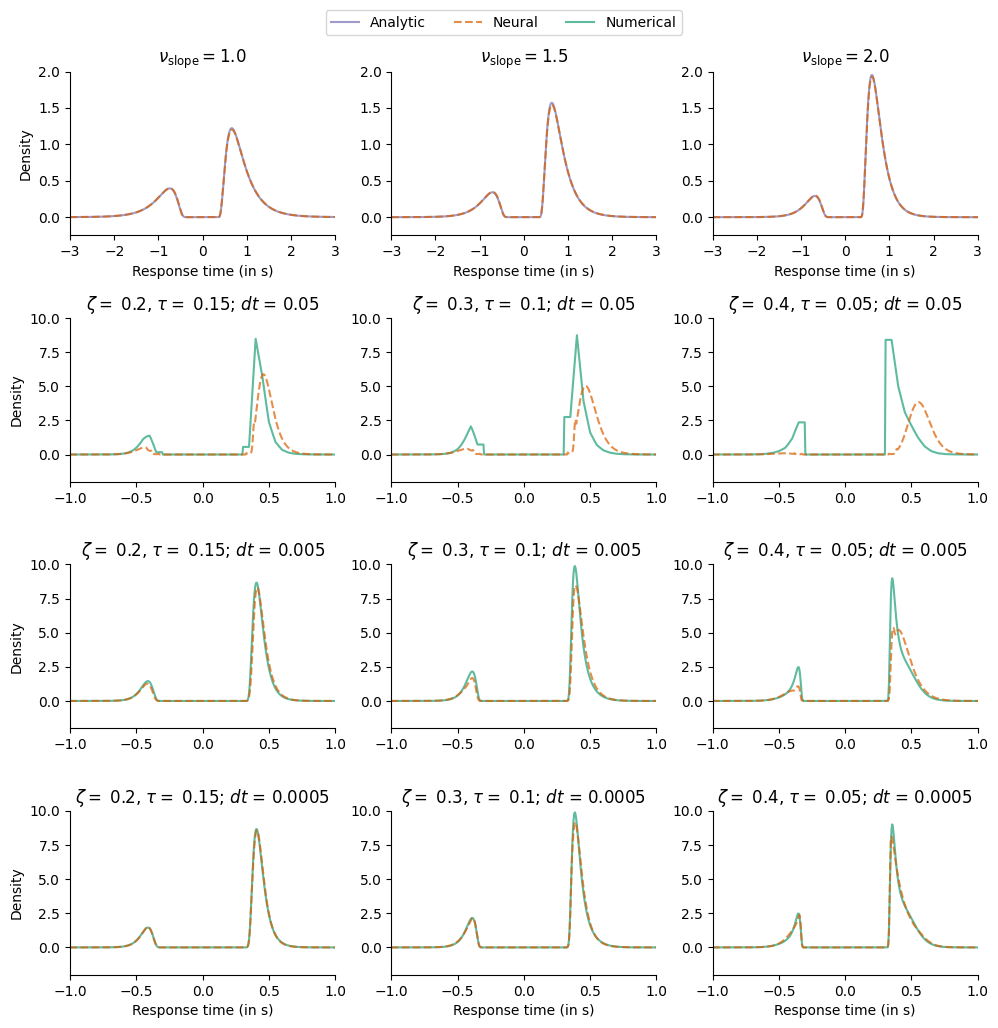

In [10]:
sort_idx = jnp.argsort(data_rev[:, 0])
x_sorted = data_rev[sort_idx, 0]

fig, axarr = plt.subplots(4, 3, figsize=(10, 10))

legend_handles = {}

for i, ax in enumerate(axarr[0]):
    l1, = ax.plot(x_sorted, jnp.exp(ll_rdm_analytical[i])[sort_idx], alpha=0.7, color="#7570b3", label="Analytic")
    l2, = ax.plot(x_sorted, jnp.exp(ll_rdm_nn[i])[sort_idx], "--", alpha=0.7, color="#d95f02", label="Neural")
    legend_handles.setdefault("Analytic", l1)
    legend_handles.setdefault("Neural", l2)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.25, 2.0)
    ax.set_title(r"$\nu_\text{slope} =$" + str(rdm_params[i][1]))
    ax.set_xlabel("Response time (in s)")
    if i == 0:
        ax.set_ylabel("Density")

for dt, ax_row in zip(dt_grid, axarr[1:]):
    for i, ax in enumerate(ax_row):
        l3, = ax.plot(x_sorted, jnp.exp(ll_dict_crdm_volterra[dt][i])[sort_idx], alpha=0.7, color="#1b9e77", label="Numerical")
        l4, = ax.plot(x_sorted, jnp.exp(ll_dict_crdm_nn[dt][i])[sort_idx], "--", alpha=0.7, color="#d95f02", label="Neural")
        legend_handles.setdefault("Numerical", l3)
        legend_handles.setdefault("Neural", l4)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-2, 10)
        ax.set_title(f"$\\zeta =$ {crdm_params[i][2]}, $\\tau =$ {crdm_params[i][3]}; $dt$ = {dt}")
        if dt == 0.0005:
            ax.set_xlabel("Response time (in s)")
        if i == 0:
            ax.set_ylabel("Density")

fig.legend(
    handles=list(legend_handles.values()),
    labels=list(legend_handles.keys()),
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout()
plt.savefig('densities/likelihood_comparison.png', dpi=150, bbox_inches='tight')
plt.show()